# Selecting PCA components with column-wise cross-validation

`column_wise_k_fold_pca_cv` selects a parsimonious number of principal components by asking whether PCA scores from one group of variables can predict a held-out group. It is intended for complete, numeric Phase I reference data.

## 1. Generate correlated process measurements

This example has six measured variables generated from two latent process factors. A small amount of measurement noise prevents the data from being exactly rank two.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pca_tools import column_wise_k_fold_pca_cv

rng = np.random.default_rng(2026)
n_observations = 150
latent = rng.normal(size=(n_observations, 2))
loadings = np.array([
    [1.0, 0.2], [0.8, -0.4], [0.4, 1.0],
    [-0.3, 0.9], [0.7, 0.6], [-0.6, 0.5],
])
reference_data = pd.DataFrame(
    latent @ loadings.T + rng.normal(scale=0.08, size=(n_observations, 6)),
    columns=[f"measurement_{i}" for i in range(1, 7)],
)
reference_data.head()

,measurement_1,measurement_2,measurement_3,measurement_4,measurement_5,measurement_6
0,-0.741457,-0.813859,0.010060,0.582638,-0.405695,0.730299
1,-1.626154,-2.217214,0.584982,1.740533,-0.511929,1.885840
2,0.505567,0.621035,-0.020781,-0.512973,0.198832,-0.522026
3,-0.181393,-0.419352,0.118944,0.355736,-0.012867,0.295646
4,-0.339574,-0.142266,-0.419836,-0.137223,-0.367711,0.174313


## 2. Run column-wise k-fold CV

With three folds, two variables are held out at a time and PCA is fitted to the other four. Therefore at most four components are feasible. `improvement_tol=0.01` stops once an added component improves PRESS by less than 1%.

In [2]:
n_components, press_scores = column_wise_k_fold_pca_cv(
    reference_data,
    n_splits=3,
    max_components=4,
    improvement_tol=0.01,
)

print(f"Selected components: {n_components}")
pd.Series(press_scores, index=np.arange(1, len(press_scores) + 1), name="PRESS")

Selected components: 2


1    691.266364
2      9.975943
3      9.923145
Name: PRESS, dtype: float64

## 3. Inspect PRESS

Lower PRESS means the PCA scores predict unseen variables more accurately. If evaluation stops early, the last plotted count was evaluated only to determine that the preceding count was sufficiently parsimonious.

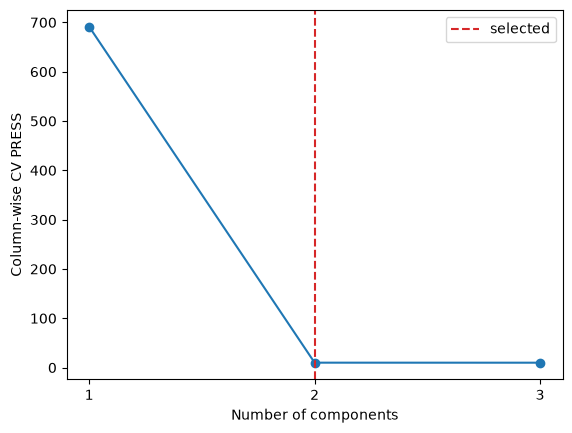

In [3]:
candidate_counts = np.arange(1, len(press_scores) + 1)
plt.plot(candidate_counts, press_scores, marker="o")
plt.axvline(n_components, color="tab:red", linestyle="--", label="selected")
plt.xlabel("Number of components")
plt.ylabel("Column-wise CV PRESS")
plt.xticks(candidate_counts)
plt.legend()
plt.show()

## Takeaway

Use the selected count as evidence alongside process knowledge and diagnostic plots. The function standardizes variables internally and excludes rows with missing values; impute or otherwise resolve missing reference measurements before using the result to fit a monitoring model.